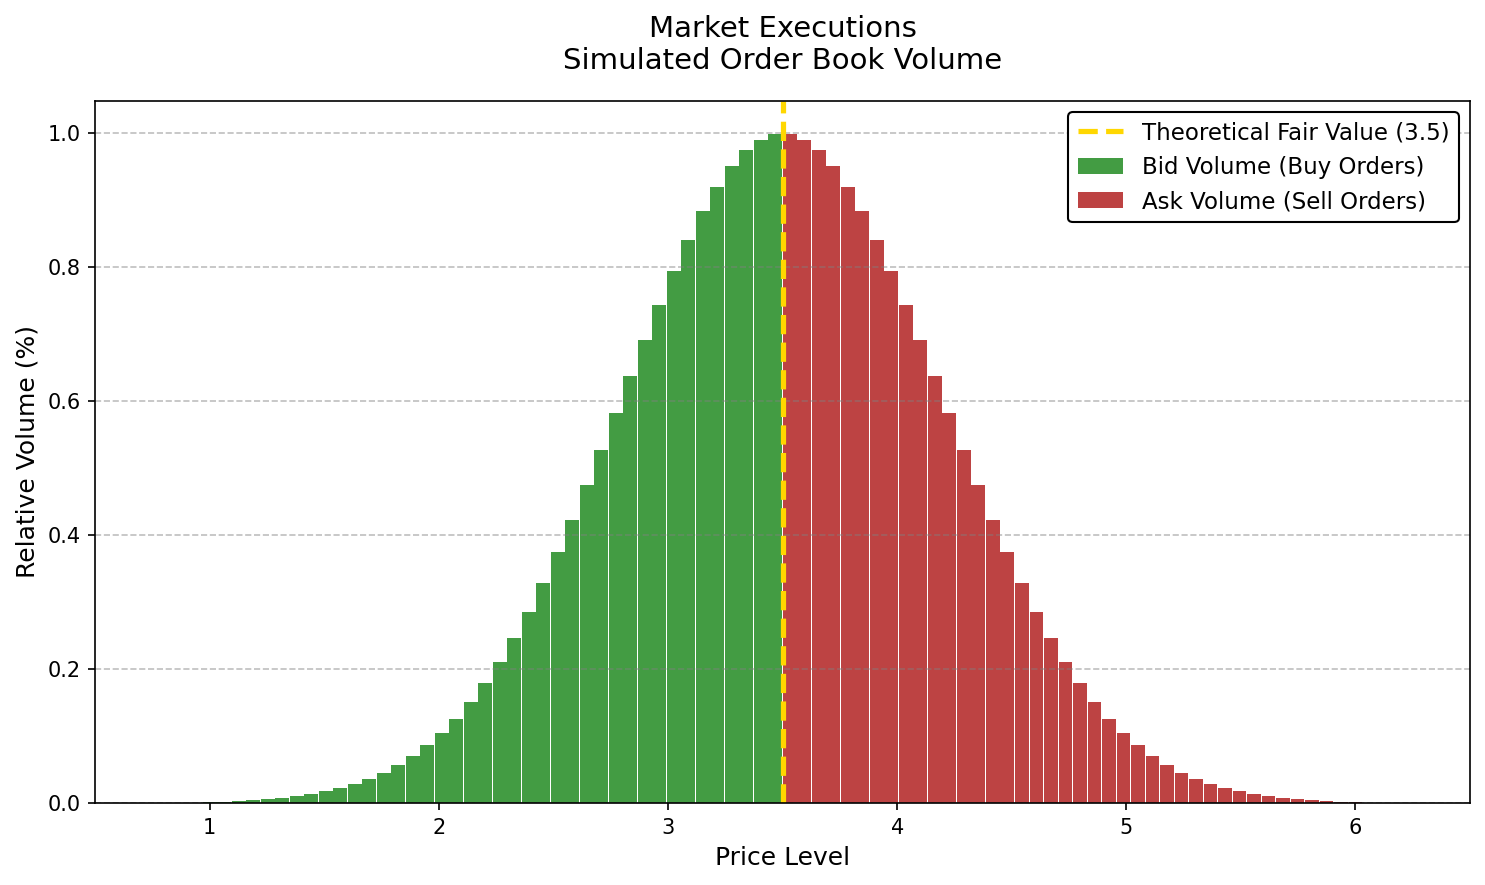

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Figure 1.6(a) — Simulated order book
# This notebook creates a stylized order book around a theoretical fair value
# It is used as an illustrative example in Chapter 1 of the thesis

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Chart parameters
fair_value = 3.5
x = np.linspace(1, 6, 80)

# Simulate a normal-shaped distribution for order volumes
# The market maker concentrates bid and ask volumes around the fair value
y_volume = np.exp(-((x - fair_value) ** 2) / (2 * 0.7 ** 2))

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Bid orders are placed below fair value, while ask orders are placed above it
bids = x < fair_value
asks = x >= fair_value

ax.bar(
    x[bids],
    y_volume[bids],
    width=0.06,
    color="forestgreen",
    alpha=0.85,
    label="Bid Volume (Buy Orders)"
)

ax.bar(
    x[asks],
    y_volume[asks],
    width=0.06,
    color="firebrick",
    alpha=0.85,
    label="Ask Volume (Sell Orders)"
)

ax.axvline(
    fair_value,
    color="gold",
    linestyle="--",
    linewidth=2.5,
    label="Theoretical Fair Value (3.5)"
)

ax.set_title(
    "Market Executions\nSimulated Order Book Volume",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Price Level", fontsize=12)
ax.set_ylabel("Relative Volume (%)", fontsize=12)
ax.set_xlim(0.5, 6.5)

ax.grid(False)
ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.5)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

# Legend formatting
ax.legend(
    fontsize=11,
    loc="upper right",
    frameon=True,
    framealpha=1,
    edgecolor="black"
)

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_1_6a_order_book.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()